In [1]:
import numpy as np
import netket as nk
import jax
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from scipy.ndimage import uniform_filter1d
import os
from tqdm import tqdm

In [25]:
N = 4
data_file = f"../data/N{N}/results_N{N}_vs_T.json"
with open(data_file, "r") as f:
    data = json.load(f)

T_array      = np.array(data["T"])
energy_results      = data["energy"]
entropy_results     = data["entropy"]
free_energy_results = data["free_energy"]
param_index  = data["param_index"]

In [26]:
from netket.operator.spin import sigmax, sigmaz

def hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended):
    H_system = 0
    H_extended = 0
    for i in range(N):
        H_system+= h_x * sigmax(hi_system, i)
        H_system+= h_z * sigmaz(hi_system, i)
        H_system += J_ZZ * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)
        H_system += J_XX * sigmax(hi_system, i) @ sigmax(hi_system, (i + 1) % N)
        H_extended += h_x * sigmax(hi_extended, i)
        H_extended += h_z * sigmaz(hi_extended, i)
        H_extended += J_ZZ * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
        H_extended += J_XX * sigmax(hi_extended, i) @ sigmax(hi_extended, (i + 1) % N)
    return H_system, H_extended

J_ZZ       = -1.0
J_XX       = 0.0
h_x        = -1.5
h_z        = 0.0
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended)

In [27]:
save = True
jump_lines = False
derivative = False 
fontsize = 14

if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

def set_ylim_robust(ax, data_arrays, percentile=97):
    all_vals = np.concatenate([np.array(d).flatten() for d in data_arrays])
    all_vals = all_vals[np.isfinite(all_vals)]
    vmin = np.percentile(all_vals, 100 - percentile)
    vmax = np.percentile(all_vals, percentile)
    margin = 0.1 * (vmax - vmin)
    ax.set_ylim(vmin - margin, vmax + margin)

def smooth_and_diff(y, x, window=20):
    y_smooth = uniform_filter1d(np.array(y, dtype=float), size=window, mode='nearest')
    return np.gradient(y_smooth, x)

H_matrix = H_system.to_dense()
eigvals, eigvecs = np.linalg.eigh(H_matrix)

def compute_jump_temperatures(evals, tol=1e-10):
    unique_evals = []
    for e in evals:
        if not unique_evals or abs(e - unique_evals[-1]) > tol:
            unique_evals.append(e)
    unique_evals = np.array(unique_evals)
    T_jumps = []
    for n in range(1, len(unique_evals)):
        weights = unique_evals[n] - unique_evals[:n]
        E_bar = np.dot(unique_evals[:n], weights) / weights.sum()
        T_jumps.append((unique_evals[n] - E_bar) / 2)
    return np.array(T_jumps)

def canonical_ensemble(eigvals, eigvecs, T):
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)
    pops = np.exp(log_pops)
    pops /= pops.sum()
    energy = np.sum(pops * eigvals)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    return energy - T * S_VN, energy, S_VN

def renyi_exact(T, eigvals, tol=1e-12):
    from scipy.optimize import brentq

    eigvals = np.array(eigvals, dtype=float)

    def mre_weights(E_perp):
        w = np.maximum(0.0, E_perp - eigvals)
        Z = w.sum()
        if Z < tol:
            return None
        return w / Z

    def f_root(E_perp):
        w = mre_weights(E_perp)
        if w is None:
            return E_perp
        E_bar = np.dot(w, eigvals)
        return E_perp - (2 * T + E_bar)

    E_min = eigvals.min()
    E_max = eigvals.max() + 4 * T

    try:
        E_perp = brentq(f_root, E_min, E_max, xtol=1e-12)
    except ValueError:
        w = np.zeros(len(eigvals))
        w[0] = 1.0
    else:
        w = mre_weights(E_perp)

    E = np.dot(w, eigvals)
    purity = np.sum(w**2)
    S2 = -np.log(purity)
    F = E - T * S2

    return F, E, S2

temperatures = np.linspace(0.05, 4, 200)
F_arr, E_arr, S_arr = np.array([canonical_ensemble(eigvals, eigvecs, T) for T in temperatures]).T
F_R, E_R, S2_R = np.array([renyi_exact(T, eigvals) for T in temperatures]).T

if jump_lines:
    T_jumps = compute_jump_temperatures(eigvals)
    T_jumps_visible = T_jumps[T_jumps <= temperatures[-1]]
cmap = plt.cm.tab10

def add_jump_lines(ax):
    for i, Tn in enumerate(T_jumps_visible):
        ax.axvline(Tn, color=cmap(i % 10), lw=1.0, ls='--', alpha=0.7)

if derivative:
    SMOOTH_WINDOW = 20
    PERCENTILE    = 97

    dF_dT_renyi = smooth_and_diff(free_energy_results, T_array, window=SMOOTH_WINDOW)
    dE_dT_renyi = smooth_and_diff(energy_results,      T_array, window=SMOOTH_WINDOW)
    dS_dT_renyi = smooth_and_diff(entropy_results,     T_array, window=SMOOTH_WINDOW)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0,0].plot(temperatures, F_arr, color='C0', label=r'$F_\mathrm{Gibbs}$')
axes[0,0].plot(temperatures, F_R, color='green', label=r'$F_\mathrm{Renyi} \, (ED)$')
axes[0,0].plot(T_array, free_energy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$F_\mathrm{Renyi}$')

axes[0,0].set_ylabel(r'$F$')
axes[0,0].set_title(r'(a) Free energy')
axes[0,0].set_xlabel(r'$T$')
axes[0,0].legend(fontsize=fontsize-1)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(temperatures, E_arr, color='C0', label=r'$\langle H\rangle_\mathrm{Gibbs}$')
axes[0,1].plot(temperatures, E_R, color='green', label=r'$\langle H\rangle_\mathrm{Renyi} \, (ED)$')
axes[0,1].plot(T_array, energy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$\langle H\rangle_\mathrm{Renyi}$')

axes[0,1].set_ylabel(r'$\langle H\rangle$')
axes[0,1].set_title(r'(b) Energy')
axes[0,1].set_xlabel(r'$T$')
axes[0,1].legend(fontsize=fontsize-1)
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(temperatures, S_arr, color='C0', label=r'$S_\mathrm{VN}$')
axes[0,2].plot(temperatures, S2_R, color='green', label=r'$S_\mathrm{Renyi} \, (ED)$')
axes[0,2].plot(T_array, entropy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$S_2$')

axes[0,2].set_ylabel(r'$S$')
axes[0,2].set_title(r'(c) Entropy')
axes[0,2].set_xlabel(r'$T$')
axes[0,2].legend(fontsize=fontsize-1)
axes[0,2].grid(True, alpha=0.3)

if derivative:
    axes[1,0].scatter(T_array, dF_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dF/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,0], [dF_dT_renyi], percentile=PERCENTILE)
    axes[1,0].set_xlabel(r'$T$')
    axes[1,0].set_ylabel(r'$dF/dT$')
    axes[1,0].set_title(r'$dF/dT$')
    axes[1,0].legend(fontsize=fontsize-1)
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].scatter(T_array, dE_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dE/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,1], [dE_dT_renyi], percentile=PERCENTILE)
    axes[1,1].set_xlabel(r'$T$')
    axes[1,1].set_ylabel(r'$dE/dT$')
    axes[1,1].set_title(r'$d\langle H\rangle/dT$')
    axes[1,1].legend(fontsize=fontsize-1)
    axes[1,1].grid(True, alpha=0.3)

    axes[1,2].scatter(T_array, dS_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dS_2/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,2], [dS_dT_renyi], percentile=PERCENTILE)
    axes[1,2].set_xlabel(r'$T$')
    axes[1,2].set_ylabel(r'$dS_2/dT$')
    axes[1,2].set_title(r'$dS_2/dT$')
    axes[1,2].legend(fontsize=fontsize-1)
    axes[1,2].grid(True, alpha=0.3)
else:
    for j in range(3):
        axes[1,j].set_visible(False)

if jump_lines:
    for i in range(2):
        for j in range(3):
            if derivative or (not derivative and i == 0):
                if axes[i,j].get_visible():
                    add_jump_lines(axes[i,j])

fig.tight_layout()
if save:
    save_fig(fig, f"F_E_S_N{N}")
else: 
    plt.show()

Guardado: ../plots/MRE/F_E_S_N4.[pgf|pdf]


In [17]:
def check_temperatures(N):
    data_file = f"../data/N{N}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    return np.array(T_list)

def load_params(N, T, vstate):
    data_file = f"../data/N{N}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    # buscar T más cercana
    idx = int(np.argmin(np.abs(np.array(T_list) - T)))
    file_idx = data["param_index"][idx]
    filename = f"../data/N{N}/params/params_{file_idx:04d}.msgpack"
    with open(filename, "rb") as f:
        params = serialization.from_bytes(vstate.parameters, f.read())
    vstate.parameters = params

def canonical_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el ensemble canónico a temperatura T.

    Parámetros
    ----------
    O : NetKet operator
    T : float
    eigvals : ndarray
    eigvecs : ndarray

    Returns
    -------
    float
    """

    # convertir operador a matriz densa
    O_matrix = O.to_dense()

    # poblaciones de Boltzmann (estables numéricamente)
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)

    pops = np.exp(log_pops)
    pops /= pops.sum()

    # <n|O|n>
    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    )

    # promedio térmico
    return np.sum(pops * O_diag).real

def renyi_expectation(O, vstate):
    """Expectation value <O> en el ensemble de Rényi."""
    return float(vstate.expect(O).mean.real)

def renyi_exact_weights(T, eigvals, tol=1e-12):
    """
    Devuelve los pesos exactos w_k del MRE (alpha=2).
    """

    from scipy.optimize import brentq

    eigvals = np.array(eigvals, dtype=float)

    def mre_weights(E_perp):
        w = np.maximum(0.0, E_perp - eigvals)
        Z = w.sum()
        if Z < tol:
            return None
        return w / Z

    def f_root(E_perp):
        w = mre_weights(E_perp)
        if w is None:
            return E_perp
        E_bar = np.dot(w, eigvals)
        return E_perp - (2 * T + E_bar)

    E_min = eigvals.min()
    E_max = eigvals.max() + 4 * T

    try:
        E_perp = brentq(f_root, E_min, E_max, xtol=1e-12)
        w = mre_weights(E_perp)

    except ValueError:
        # ground state
        w = np.zeros(len(eigvals))
        w[0] = 1.0

    return w

def renyi_exact_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el MRE exacto (alpha=2).
    """

    w = renyi_exact_weights(T, eigvals)

    # operador en base de energía
    O_matrix = O.to_dense()

    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    ).real

    return float(np.dot(w, O_diag))

In [18]:
save = True             
jump_temperatures = False    
derivative = False  
fontsize = 14

if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        import os
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
O_xx = sum(sigmax(hi_system, i) @ sigmax(hi_system, (i+1) % N) 
           for i in range(N)) / N
O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i+1) % N) 
           for i in range(N)) / N

O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
O_xx_ext = sum(sigmax(hi_extended, i) @ sigmax(hi_extended, (i+1) % N)
               for i in range(N)) / N
O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i+1) % N)
               for i in range(N)) / N

sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

T_array_compare = check_temperatures(N)

renyi_sx, renyi_sxx, renyi_szz = [], [], []
gibbs_sx, gibbs_sxx, gibbs_szz = [], [], []
exact_renyi_sx, exact_renyi_sxx, exact_renyi_szz = [], [], []

T_filtradas = [T for T in T_array_compare if T >= 0.05]
for T in tqdm(T_filtradas, desc=f"Procesando temperaturas vstate"):
    load_params(N, T, vstate)
    renyi_sx.append(renyi_expectation(O_x_ext, vstate))
    renyi_sxx.append(renyi_expectation(O_xx_ext, vstate))
    renyi_szz.append(renyi_expectation(O_zz_ext, vstate))

for T in tqdm(temperatures, desc=f"Procesando temperaturas ED"):
    gibbs_sx.append(canonical_expectation(O_x, T, eigvals, eigvecs))
    gibbs_sxx.append(canonical_expectation(O_xx, T, eigvals, eigvecs))
    gibbs_szz.append(canonical_expectation(O_zz, T, eigvals, eigvecs))
    exact_renyi_sx.append(renyi_exact_expectation(O_x, T, eigvals, eigvecs))
    exact_renyi_sxx.append(renyi_exact_expectation(O_xx, T, eigvals, eigvecs))
    exact_renyi_szz.append(renyi_exact_expectation(O_zz, T, eigvals, eigvecs))

T_plot = T_array_compare[T_array_compare >= 0.05]

if derivative:
    from scipy.signal import savgol_filter
    
    def smooth_and_derivative(y, x, window=21, polyorder=3):
        if len(y) < window:
            window = len(y) if len(y) % 2 == 1 else len(y) - 1
        if window < polyorder + 2:
            window = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3
        y_smooth = savgol_filter(y, window, polyorder)
        dy_dx = np.gradient(y_smooth, x)
        return dy_dx
    
    window_size = min(21, len(T_plot) if len(T_plot) % 2 == 1 else len(T_plot) - 1)
    d_renyi_sx_dT = smooth_and_derivative(renyi_sx, T_plot, window=window_size, polyorder=3)
    d_renyi_sxx_dT = smooth_and_derivative(renyi_sxx, T_plot, window=window_size, polyorder=3)
    d_renyi_szz_dT = smooth_and_derivative(renyi_szz, T_plot, window=window_size, polyorder=3)
    
    d_gibbs_sx_dT = smooth_and_derivative(gibbs_sx, temperatures, window=21, polyorder=3)
    d_gibbs_sxx_dT = smooth_and_derivative(gibbs_sxx, temperatures, window=21, polyorder=3)
    d_gibbs_szz_dT = smooth_and_derivative(gibbs_szz, temperatures, window=21, polyorder=3)
    
    d_exact_renyi_sx_dT = smooth_and_derivative(exact_renyi_sx, temperatures, window=21, polyorder=3)
    d_exact_renyi_sxx_dT = smooth_and_derivative(exact_renyi_sxx, temperatures, window=21, polyorder=3)
    d_exact_renyi_szz_dT = smooth_and_derivative(exact_renyi_szz, temperatures, window=21, polyorder=3)

def add_jump_line_temperatures(ax, temperatures_array):
    if jump_temperatures:
        try:
            if 'eigvals' in globals():
                T_jumps = compute_jump_temperatures(eigvals)
                T_jumps_visible = T_jumps[T_jumps <= temperatures_array[-1]]
                cmap = plt.cm.tab10
                for i, Tn in enumerate(T_jumps_visible):
                    ax.axvline(Tn, color=cmap(i % 10), lw=1.0, ls='--', alpha=0.5)
        except:
            pass

if derivative:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax_val_0 = axes[0, 0] if derivative else axes[0]
ax_val_0.plot(temperatures, gibbs_sx, label=r'$\langle\sigma^x\rangle$ Gibbs', color='C0')
ax_val_0.scatter(T_plot, renyi_sx, s=10, color='orange', label=r'$\langle\sigma^x\rangle$ Rényi (vstate)', zorder=3)
ax_val_0.plot(temperatures, exact_renyi_sx, color='green', ls='--', label=r'$\langle\sigma^x\rangle$ Rényi ED')
ax_val_0.set_xlabel(r'$T$')
ax_val_0.set_ylabel(r'$\langle\sigma^x\rangle$')
ax_val_0.set_title(r'(a) $\langle\sigma^x\rangle$')
ax_val_0.legend(fontsize=fontsize-1)
ax_val_0.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_0, temperatures)

if derivative:
    ax_der_0 = axes[1, 0]
    ax_der_0.scatter(T_plot, d_renyi_sx_dT, s=15, color='orange', 
                     label=r'$d\langle\sigma^x\rangle/dT$ Rényi (vstate)', zorder=3)
    ax_der_0.plot(temperatures, d_gibbs_sx_dT, color='C0', 
                  label=r'$d\langle\sigma^x\rangle/dT$ Gibbs')
    ax_der_0.plot(temperatures, d_exact_renyi_sx_dT, color='green', ls='--', 
                  label=r'$d\langle\sigma^x\rangle/dT$ Rényi ED')
    ax_der_0.set_xlabel(r'$T$')
    ax_der_0.set_ylabel(r'$d\langle\sigma^x\rangle/dT$')
    ax_der_0.set_title(r'Derivada $\langle\sigma^x\rangle$')
    ax_der_0.legend(fontsize=fontsize-1)
    ax_der_0.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_0, temperatures)

ax_val_1 = axes[0, 1] if derivative else axes[1]
ax_val_1.plot(temperatures, gibbs_sxx, label=r'$\Gamma^{x,x}$ Gibbs', color='C0')
ax_val_1.scatter(T_plot, renyi_sxx, s=10, color='orange', label=r'$\Gamma^{x,x}$ Rényi (vstate)', zorder=3)
ax_val_1.plot(temperatures, exact_renyi_sxx, color='green', ls='--', label=r'$\Gamma^{x,x}$ Rényi ED')
ax_val_1.set_xlabel(r'$T$')
ax_val_1.set_ylabel(r'$\Gamma^{x,x}$')
ax_val_1.set_title(r'(b) $\Gamma^{x,x}$')
ax_val_1.legend(fontsize=fontsize-1)
ax_val_1.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_1, temperatures)

if derivative:
    ax_der_1 = axes[1, 1]
    ax_der_1.scatter(T_plot, d_renyi_sxx_dT, s=15, color='orange', 
                     label=r'$d\Gamma^{x,x}/dT$ Rényi (vstate)', zorder=3)
    ax_der_1.plot(temperatures, d_gibbs_sxx_dT, color='C0', 
                  label=r'$d\Gamma^{x,x}/dT$ Gibbs')
    ax_der_1.plot(temperatures, d_exact_renyi_sxx_dT, color='green', ls='--', 
                  label=r'$d\Gamma^{x,x}/dT$ Rényi ED')
    ax_der_1.set_xlabel(r'$T$')
    ax_der_1.set_ylabel(r'$d\Gamma^{x,x}/dT$')
    ax_der_1.set_title(r'Derivada $\Gamma^{x,x}$')
    ax_der_1.legend(fontsize=fontsize-1)
    ax_der_1.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_1, temperatures)

ax_val_2 = axes[0, 2] if derivative else axes[2]
ax_val_2.plot(temperatures, gibbs_szz, label=r'$\Gamma^{z,z}$ Gibbs', color='C0')
ax_val_2.scatter(T_plot, renyi_szz, s=10, color='orange', label=r'$\Gamma^{z,z}$ Rényi (vstate)', zorder=3)
ax_val_2.plot(temperatures, exact_renyi_szz, color='green', ls='--', label=r'$\Gamma^{z,z}$ Rényi ED')
ax_val_2.set_xlabel(r'$T$')
ax_val_2.set_ylabel(r'$\Gamma^{z,z}$')
ax_val_2.set_title(r'(c) $\Gamma^{z,z}$')
ax_val_2.legend(fontsize=fontsize-1)
ax_val_2.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_2, temperatures)

if derivative:
    ax_der_2 = axes[1, 2]
    ax_der_2.scatter(T_plot, d_renyi_szz_dT, s=15, color='orange', 
                     label=r'$d\Gamma^{z,z}/dT$ Rényi (vstate)', zorder=3)
    ax_der_2.plot(temperatures, d_gibbs_szz_dT, color='C0', 
                  label=r'$d\Gamma^{z,z}/dT$ Gibbs')
    ax_der_2.plot(temperatures, d_exact_renyi_szz_dT, color='green', ls='--', 
                  label=r'$d\Gamma^{z,z}/dT$ Rényi ED')
    ax_der_2.set_xlabel(r'$T$')
    ax_der_2.set_ylabel(r'$d\Gamma^{z,z}/dT$')
    ax_der_2.set_title(r'Derivada $\Gamma^{z,z}$')
    ax_der_2.legend(fontsize=fontsize-1)
    ax_der_2.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_2, temperatures)

plt.tight_layout()

if save:
    save_fig(fig, f"Observables_N{N}")
else:
    plt.show()

Procesando temperaturas ED: 100%|██████████| 200/200 [01:12<00:00,  2.77it/s]


Guardado: ../plots/MRE/Observables_N4.[pgf|pdf]


In [30]:
save = True
jump_temperatures = False
derivative = False
fontsize = 14

N_list = [4, 6, 8, 10, 12]
temperatures = np.linspace(0.05, 4.0, 200)

def gibbs_thermodynamic_limit(T_array, J, h):
    """
    Calcula observables en el límite termodinámico para el modelo de Ising
    con campo transversal usando la solución analítica.
    """
    Nk = 4000
    k = np.linspace(0, np.pi, Nk)
    dk = np.pi / Nk
    energies_td = []
    sx_td = []
    szz_td = [] 
    for T in T_array:
        beta = 1.0 / T
        eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
        tanh_term = np.tanh(beta * eps_k / 2)
        # Energía por sitio 
        e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
        # <σx>
        mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
        # <σz σz>
        corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
        energies_td.append(e)
        szz_td.append(corr*2)
        sx_td.append(mx*2)   
    return np.array(energies_td), np.array(sx_td), np.array(szz_td)

print("Calculando límite termodinámico de Gibbs...")
energies_td, sx_td, szz_td = gibbs_thermodynamic_limit(temperatures, -J_ZZ, -h_x)
results = {}

for N in N_list:
    print(f"\nCalculando MRE N = {N}...")
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=N)  
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, 0, h_x, 0, N, hi_system, hi_extended)
    
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i+1) % N) 
               for i in range(N)) / N
    
    H_matrix = H_system.to_dense()
    eigvals, eigvecs = np.linalg.eigh(H_matrix)
    
    energies_renyi = []
    sx_renyi = []
    szz_renyi = []
    energies_gibbs = []
    sx_gibbs = []
    szz_gibbs = []
    energy_density = []
    
    for T in tqdm(temperatures, desc=f"Temperaturas N={N}"):
        F, E_R, S2_R = renyi_exact(T, eigvals) 
        energy_density.append(E_R / N)
        
        sx_renyi.append(renyi_exact_expectation(O_x, T, eigvals, eigvecs))
        szz_renyi.append(renyi_exact_expectation(O_zz, T, eigvals, eigvecs))
        
        sx_gibbs.append(canonical_expectation(O_x, T, eigvals, eigvecs))
        szz_gibbs.append(canonical_expectation(O_zz, T, eigvals, eigvecs))
    
    results[N] = {
        'energy_density': np.array(energy_density),
        'sx_renyi': np.array(sx_renyi),
        'szz_renyi': np.array(szz_renyi),
    }

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(N_list)))

ax1 = axes[0]
for idx, N in enumerate(N_list):
    color = colors[idx]
    ax1.plot(results[N]['energy_density'], results[N]['sx_renyi'], 
             '-', color=color, linewidth=2, label=f'N={N} (MRE)')
ax1.plot(energies_td, sx_td, 'k-', linewidth=2.5, label=r'Gibbs ($N\to\infty$)')
ax1.set_xlabel(r'$\langle H \rangle / N$')
ax1.set_ylabel(r'$\langle \sigma^x \rangle$')
ax1.set_title(r'(a) $\langle\sigma^x\rangle$')
ax1.legend(fontsize=fontsize-1)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for idx, N in enumerate(N_list):
    color = colors[idx]
    ax2.plot(results[N]['energy_density'], results[N]['szz_renyi'], 
             '-', color=color, linewidth=2, label=f'N={N} (MRE)')
ax2.plot(energies_td, szz_td, 'k-', linewidth=2.5, label=r'Gibbs ($N\to\infty$)')
ax2.set_xlabel(r'$\langle H \rangle / N$')
ax2.set_ylabel(r'$\Gamma^{z,z}$')
ax2.set_title(r'(b) $\Gamma^{z,z}$')
ax2.legend(fontsize=fontsize-1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

if save:
    import matplotlib
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })
    
    def save_fig(fig, name, subdir="plots/MRE"):
        import os
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")
    
    save_fig(fig, "convergence_MRE_to_Gibbs")
else:
    plt.show()

Calculando límite termodinámico de Gibbs...

Calculando MRE N = 4...


Temperaturas N=4: 100%|██████████| 200/200 [00:46<00:00,  4.33it/s]



Calculando MRE N = 6...


Temperaturas N=6: 100%|██████████| 200/200 [00:49<00:00,  4.01it/s]



Calculando MRE N = 8...


...


Calculando MRE N = 10...


Temperaturas N=10: 100%|██████████| 200/200 [01:15<00:00,  2.64it/s]



Calculando MRE N = 12...


Temperaturas N=12: 100%|██████████| 200/200 [12:00<00:00,  3.60s/it]


Guardado: ../plots/MRE/convergence_MRE_to_Gibbs.[pgf|pdf]



Procesando N = 3


N=3: 100%|██████████| 206/206 [00:02<00:00, 74.35it/s]



Procesando N = 4


N=4: 100%|██████████| 201/201 [00:03<00:00, 63.30it/s]



Procesando N = 6


N=6: 100%|██████████| 191/191 [00:06<00:00, 29.87it/s]



Procesando N = 10


N=10: 100%|██████████| 40/40 [00:28<00:00,  1.41it/s]


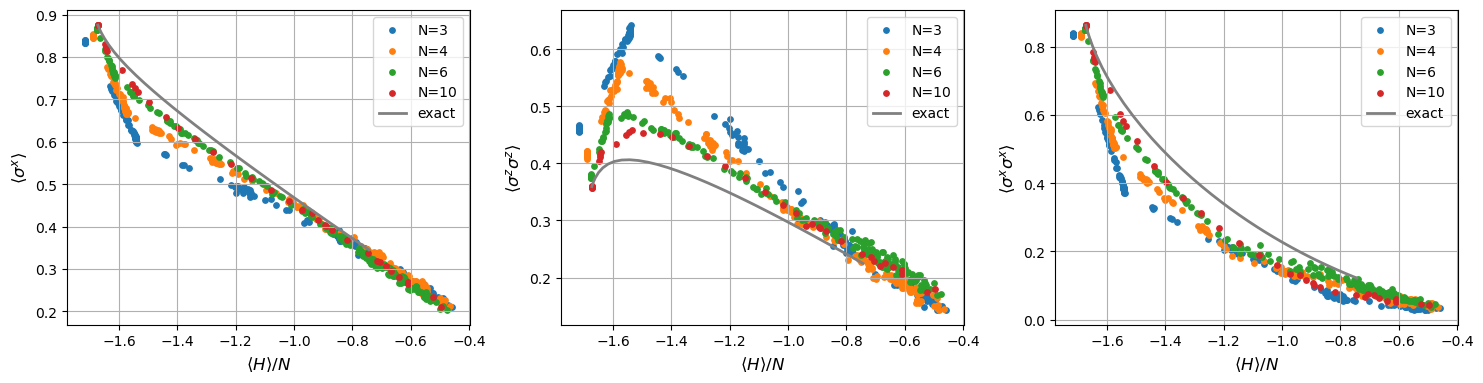

In [25]:
N_list = [3, 4, 6, 10]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  

exact_drawn = True

for N in N_list:
    T_array = check_temperatures(N)
    T_array = T_array[T_array >= 0.05]
    if N == 10:
        exact_drawn = False
    print(f"\nProcesando N = {N}")

    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended)

    # diagonalización exacta
    if not exact_drawn:
        H_matrix = H_system.to_dense()
        eigvals, eigvecs = np.linalg.eigh(H_matrix)

    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_xx = sum(sigmax(hi_system, i) @ sigmax(hi_system, (i + 1) % N) for i in range(N)) / N  
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N
    O_xx_ext = sum(sigmax(hi_extended, i) @ sigmax(hi_extended, (i + 1) % N) for i in range(N)) / N 

    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    if N==30:
        model = nk.models.ARNNDense(hilbert=hi_extended, layers=2, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N==30: vstate.chunk_size=256
    if N>40:
        vstate.chunk_size = 256*4


    energies_renyi = []
    sx_renyi = []
    szz_renyi = []
    sxx_renyi = []  
    energies_exact = []
    sx_exact = []
    szz_exact = []
    sxx_exact = []  

    for T in tqdm(T_array, desc=f"N={N}"):
        # Rényi
        load_params(N, T, vstate)
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr_zz = vstate.expect(O_zz_ext).mean
        corr_xx = vstate.expect(O_xx_ext).mean 
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr_zz)
        sxx_renyi.append(corr_xx)  

        if not exact_drawn:
            beta = 1.0 / T
            weights = np.exp(-beta * eigvals)
            Z = np.sum(weights)
            E_exact = np.sum(eigvals * weights) / Z
            e_density_exact = E_exact / N
            mx_exact = canonical_expectation(O_x, T, eigvals, eigvecs)
            corr_zz_exact = canonical_expectation(O_zz, T, eigvals, eigvecs)
            corr_xx_exact = canonical_expectation(O_xx, T, eigvals, eigvecs)  
            energies_exact.append(e_density_exact)
            sx_exact.append(mx_exact)
            szz_exact.append(corr_zz_exact)
            sxx_exact.append(corr_xx_exact)  

    
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")
    axes[2].scatter(energies_renyi, sxx_renyi, s=15, label=f"N={N}")  

    
    if not exact_drawn:
        axes[0].plot(energies_exact, sx_exact, color="gray", linewidth=2, label="exact")
        axes[1].plot(energies_exact, szz_exact, color="gray", linewidth=2, label="exact")
        axes[2].plot(energies_exact, sxx_exact, color="gray", linewidth=2, label="exact") 
        exact_drawn = True


axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")
axes[2].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")
axes[2].set_ylabel(r"$\langle \sigma^x \sigma^x \rangle$") 

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


Procesando N = 22


N=22:  15%|█▌        | 6/40 [00:00<00:02, 12.96it/s]


KeyboardInterrupt: 

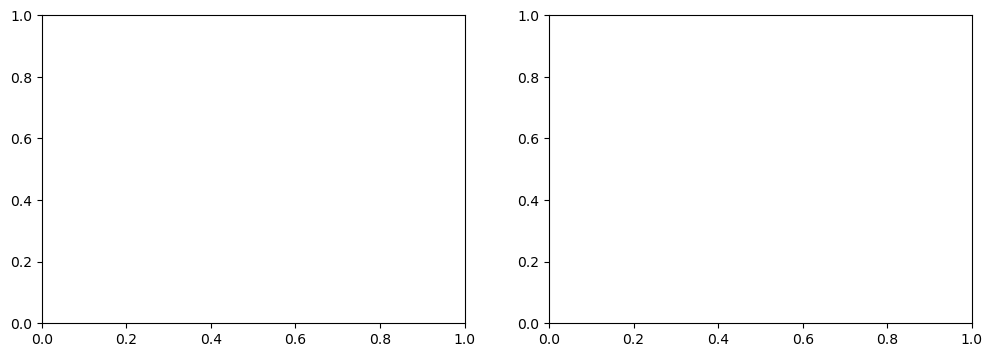

In [ ]:
N_list = [22, 30, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Límite termodinámico
Nk = 4000
k = np.linspace(0, np.pi, Nk)
dk = np.pi / Nk

J = abs(V)
h = abs(Gamma)

energies_td = []
sx_td = []         
szz_td = []

for T in T_array:
    beta = 1.0 / T
    eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
    tanh_term = np.tanh(beta * eps_k / 2)
    # Energía por sitio 
    e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
    # <σx>
    mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
    # <σz σz>
    corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
    energies_td.append(e)
    szz_td.append(corr*2)
    sx_td.append(mx*2)   

# Loop en N

for N in N_list:
    T_array = check_temperatures(N)
    T_array = T_array[T_array >= 0.05]
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)

    # Hamiltonianos
    H_system, H_extended = hamiltonian_system_and_extended(Gamma,V,N,hi_system,hi_extended)

    # Observables
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    if N==30:
        model = nk.models.ARNNDense(hilbert=hi_extended, layers=2, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N==30: vstate.chunk_size=256
    if N>40:
        vstate.chunk_size = 256*4

    energies_renyi = []
    sx_renyi = []
    szz_renyi = []

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        load_params(N, T, vstate)
        if N>50:
            vstate.chunk_size = 256
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr = vstate.expect(O_zz_ext).mean
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr)

    # Plot Rényi
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")


# Plot límite termodinámico
axes[0].plot(energies_td, sx_td, color="gray", linewidth=3, label="thermodynamic limit")
axes[1].plot(energies_td, szz_td, color="gray", linewidth=3, label="thermodynamic limit")


axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")

axes[0].grid(True)
axes[1].grid(True)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()